In [1]:
import sys
import os

from pathlib import Path
# Locate the project root containing the src folder
root = Path.cwd()
if not (root / "src").exists():
    for parent in root.parents:
        if (parent / "src").exists():
            root = parent
            break
sys.path.append(str(root))

from sklearn.pipeline import Pipeline
from src.data_preprocessing import load_and_preprocess
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, precision_recall_curve
import numpy as np

X_train, X_test, y_train, y_test, preprocessor = load_and_preprocess()

# Better pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, eval_metric='aucpr'))
])

param_dist = {
    'classifier__n_estimators': [200, 300, 400],
    'classifier__max_depth': [4, 6, 8],
    'classifier__learning_rate': [0.05, 0.1, 0.15],
    'classifier__subsample': [0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.8, 0.9, 1.0],
    'classifier__scale_pos_weight': [25, 29, 35]
}

search = RandomizedSearchCV(
    xgb_pipeline, param_dist, n_iter=30, cv=5, 
    scoring='f1', random_state=42, n_jobs=-1, verbose=1
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print("Best CV F1:", search.best_score_)

# Final model
best_model = search.best_estimator_
y_prob = best_model.predict_proba(X_test)[:, 1]

# Threshold tuning (very important for imbalanced problems)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Best threshold: {best_threshold:.3f}")
print(f"Test F1 at best threshold: {f1_scores.max():.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'classifier__subsample': 0.8, 'classifier__scale_pos_weight': 35, 'classifier__n_estimators': 400, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.15, 'classifier__colsample_bytree': 0.9}
Best CV F1: 0.7964298162900774
Best threshold: 0.794
Test F1 at best threshold: 0.8397


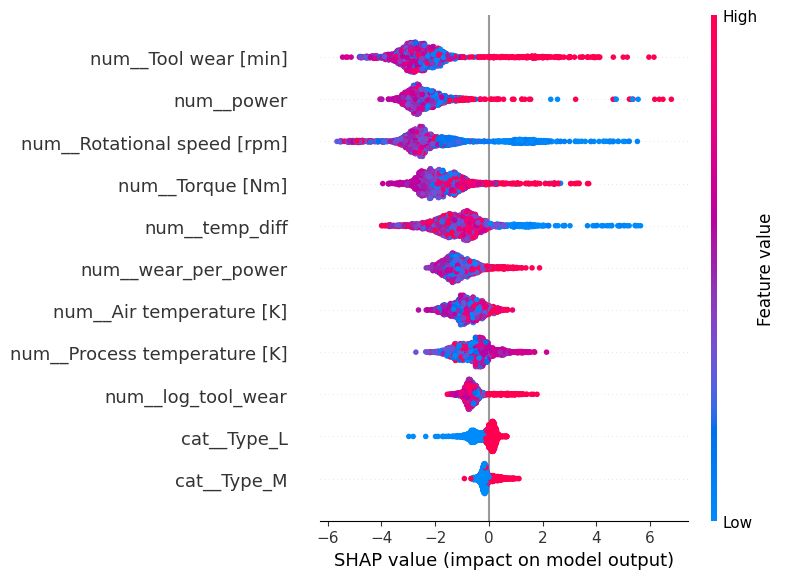

In [2]:
import shap
import matplotlib.pyplot as plt

# Get processed data
X_test_processed = best_model.named_steps['preprocessor'].transform(X_test)

explainer = shap.TreeExplainer(best_model.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_processed)

# Summary plot
shap.summary_plot(shap_values, X_test_processed, 
                  feature_names=best_model.named_steps['preprocessor'].get_feature_names_out())



In [ ]:

# Save model
import joblib

joblib.dump(preprocessor, 'models/preprocessor.pkl')

['models/preprocessor.pkl']

In [8]:
joblib.dump(best_model, 'models/xgb_best_model.pkl')

['models/xgb_best_model.pkl']

In [ ]:
import joblib

# Save the best pipeline
joblib.dump(best_model, 'models/xgb_final_model.pkl')

# Also save preprocessor separately useful for Streamlit
preprocessor = best_model.named_steps['preprocessor']
joblib.dump(preprocessor, 'models/preprocessor.pkl')

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!
